# Quick model fits on `oyExt_all.csv` and PSE-vs-conflict comparison

Fits three candidate models to the single participant `oy` (with extended ±0.45 conflicts) and overlays each model's predicted PSE-vs-conflict on top of the empirical PSEs.

**Models** (matching the three-model BMS table):
1. `lognorm`               — causal-inference averaging (log-space)
2. `fusionOnlyLogNorm`     — forced fusion (no CI)
3. `switchingFree`         — probabilistic cue switching with free p_switch per audNoise

Optimised with `scipy.optimize.minimize` via the existing `fitCausalInferenceMonteCarlo` pipeline.

Speed settings used here: `nStart = 3`, `nSimul = 2000` during fits; `nSimul = 2000` for the prediction curves. Bump both up if you want tighter results.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import json
from pathlib import Path
from scipy.optimize import minimize
from scipy.stats import norm

import loadData
import monteCarloClass

FONT_SIZE_LABEL = 18
FONT_SIZE_TITLE = 20
FONT_SIZE_LEGEND = 16
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': FONT_SIZE_LABEL,
    'axes.titlesize': FONT_SIZE_TITLE,
    'axes.labelsize': FONT_SIZE_LABEL,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})
STANDARD_S  = 0.5
STANDARD_MS = 500

## 1. Load data + snap conflicts to canonical values

In [2]:
DATA_NAME = 'oyExt_all.csv'
data, dataName = loadData.loadData(DATA_NAME, verbose=False)

CANONICAL_CONFLICTS_S = np.array([-0.45, -0.25, -0.17, -0.08, 0.0, 0.08, 0.17, 0.25, 0.45])

def snap_conflict(c, canonical=CANONICAL_CONFLICTS_S):
    return float(canonical[int(np.argmin(np.abs(canonical - c)))])

data['conflictDur'] = data['conflictDur'].apply(snap_conflict)
print('conflicts (ms):', sorted({int(round(c * 1000)) for c in data['conflictDur'].unique()}))
print('audNoise:', sorted(data['audNoise'].unique()))
print('N trials:', len(data))

conflicts (ms): [-450, -250, -170, -80, 0, 80, 170, 250, 450]
audNoise: [np.float64(0.1), np.float64(1.2)]
N trials: 2778


## 2. Fit the three models

`OmerMonteCarlo.fitCausalInferenceMonteCarlo` internally builds the binomial NLL over choice data and minimises with `scipy.minimize`. We use `sharedLambda=True` and `freeP_c=False` to keep the parameter count comparable across models.

In [3]:
MODELS = ['lognorm', 'fusionOnlyLogNorm', 'switchingFree']
DISPLAY = {
    'lognorm':           'CI averaging',
    'fusionOnlyLogNorm': 'Forced fusion',
    'switchingFree':     'Cue switching',
}
COLORS = {
    'lognorm':           '#1f77b4',
    'fusionOnlyLogNorm': '#7f7f7f',
    'switchingFree':     '#d62728',
}
PARAM_NAMES_FULL = {
    'fusionOnlyLogNorm': ['lambda', 'sigma_a1', 'sigma_v', 'sigma_a2'],
    'lognorm': ['lambda', 'sigma_a1', 'sigma_v', 'p_c', 'sigma_a2'],
    'switchingFree': ['lambda', 'sigma_a1', 'sigma_v', 'p_sw1', 'sigma_a2', 'p_sw2'],
}

from pathlib import Path
import json

MODEL_FITS_DIR = Path('model_fits_extendedConflict')


def make_model_runner(model_name, n_simul=500, n_start=1):
    mc = monteCarloClass.OmerMonteCarlo(data)
    mc.modelName        = model_name
    mc.sharedLambda     = True
    mc.freeP_c          = False
    mc.nSimul           = n_simul
    mc.nStart           = n_start
    mc.optimizationMethod = 'bads'  
    return mc


def model_type_for(mc):
    model_type = mc.modelName
    model_type += '_LapseFix' if mc.sharedLambda else '_LapseFree'
    model_type += '_contextualPrior' if mc.freeP_c else '_sharedPrior'
    return model_type


def fit_path_for(mc):
    participant_id = dataName.split('_')[0]
    return MODEL_FITS_DIR / participant_id / f'{participant_id}_{model_type_for(mc)}_fit.json'


def parameter_names_for_model(model_name, n_params=None):
    names = list(PARAM_NAMES_FULL.get(model_name, []))
    if n_params is not None and len(names) != n_params:
        names = [f'p{i}' for i in range(n_params)]
    return names


def parameter_bounds_for_model(mc, model_name=None, n_params=None):
    model_name = model_name or mc.modelName
    shared_lambda = getattr(mc, 'sharedLambda', True)
    free_p_c = getattr(mc, 'freeP_c', False)

    if model_name in ['fusionOnly', 'fusionOnlyLogNorm']:
        bounds = np.array([
            (0.001, 0.4),
            (0.01, 2.0),
            (0.01, 2.0),
            (0.01, 2.0),
        ])
        if not shared_lambda:
            bounds = np.vstack([bounds, [(0.001, 0.4), (0.001, 0.4)]])
    elif model_name == 'switchingFree':
        bounds = np.array([
            (0.001, 0.4),
            (0.0001, 2.0),
            (0.0001, 2.0),
            (0.0, 1.0),
            (0.0001, 2.0),
            (0.001, 0.4),
            (0.001, 0.4),
            (0.0, 1.0),
        ])
        if shared_lambda:
            bounds = np.delete(bounds, [5, 6], axis=0)
    elif model_name in ['gaussian', 'lognorm', 'logLinearMismatch',
                        'probabilityMatching', 'probabilityMatchingLogNorm',
                        'selection', 'switching']:
        bounds = np.array([
            (0.001, 0.4),
            (0.0001, 2.0),
            (0.0001, 2.0),
            (0.0, 1.0),
            (0.0001, 2.0),
            (0.001, 0.4),
            (0.001, 0.4),
        ])
        if free_p_c:
            bounds = np.vstack([bounds, [(0.0, 1.0)]])
        if shared_lambda:
            bounds = np.delete(bounds, [5, 6], axis=0)
    elif model_name == 'switchingWithConflict':
        bounds = np.array([
            (0.001, 0.4),
            (0.0001, 2.0),
            (0.0001, 2.0),
            (0.0, 1.0),
            (0.0001, 2.0),
            (0.001, 0.4),
            (0.001, 0.4),
            (0.1, 10.0),
        ])
        if free_p_c:
            bounds = np.insert(bounds, 7, (0.0, 1.0), axis=0)
        if shared_lambda:
            bounds = np.delete(bounds, [5, 6], axis=0)
    else:
        return {}

    names = parameter_names_for_model(model_name, n_params or len(bounds))
    return dict(zip(names, bounds.tolist()))


def ask_refit_action(prompt):
    while True:
        answer = input(prompt).strip().lower()
        if answer in {'all', 'a', 'yes all', 'y all', 'refit all', 'yes refit all', 'y refit all'}:
            return 'fit_all'
        if answer in {'yes', 'y'}:
            return 'fit'
        if answer in {'no', 'n', ''}:
            return 'load'
        print('Please type yes, no, or all.')


def fit_one_model(model_name, n_simul=2000, n_start=1):
    mc = make_model_runner(model_name, n_simul=n_simul, n_start=n_start)
    print(f'  Starting fit with nSimul={mc.nSimul}, nStart={mc.nStart}')
    t0 = time.time()
    fitted = mc.fitCausalInferenceMonteCarlo(mc.groupedData)
    dt = time.time() - t0
    nll = mc.nLLMonteCarloCausal(fitted, mc.groupedData)
    print(f'  {model_name}: fit in {dt:.1f}s, NLL={nll:.2f}, params={np.round(fitted, 3).tolist()}')
    return mc, fitted, nll


def load_existing_fit(model_name, n_simul=2000, n_start=1):
    mc = make_model_runner(model_name, n_simul=n_simul, n_start=n_start)
    path = fit_path_for(mc)
    with open(path) as f:
        payload = json.load(f)
    params = np.array(payload['fittedParams'], dtype=float)
    nll = float(payload.get('NLL', -payload['logLikelihood']))
    n_params = int(payload.get('n_params', len(params)))
    aic = float(payload.get('AIC', 2 * n_params + 2 * nll))
    bic = float(payload.get('BIC', np.log(len(data)) * n_params + 2 * nll))
    print(f'  loaded existing {model_name}: NLL={nll:.2f}, params={np.round(params, 3).tolist()}')
    return dict(mc=mc, params=params, nll=nll,
                n_params=n_params, aic=aic, bic=bic,
                param_names=payload.get('param_names', parameter_names_for_model(model_name, len(params))),
                nstart_attempts=payload.get('nstart_attempts', []))



NSTART = 5
NSIMUL = 2000

fits = {}
refit_all_for_participant = False
for m in MODELS:
    print(f'\n=== {m} ===')
    mc_check = make_model_runner(m, n_simul=NSIMUL, n_start=NSTART)  # quick check for existing fit
    existing_path = fit_path_for(mc_check)
    should_fit = True
    if existing_path.exists() and not refit_all_for_participant:
        action = ask_refit_action(
            f'Existing fit found at {existing_path}. Refit {m}? yes/no/all [no]: '
        )
        if action == 'fit_all':
            refit_all_for_participant = True
            should_fit = True
            print('  Refitting all remaining models for this participant.')
        else:
            should_fit = (action == 'fit')
    elif existing_path.exists() and refit_all_for_participant:
        print(f'  Existing fit found at {existing_path}; refitting because all was selected.')
    if should_fit:
        mc_obj, params, nll = fit_one_model(m, n_simul=NSIMUL, n_start=NSTART)
        fits[m] = dict(mc=mc_obj, params=params, nll=nll,
                       n_params=len(params),
                       aic=2 * len(params) + 2 * nll,
                       bic=np.log(len(data)) * len(params) + 2 * nll,
                       param_names=parameter_names_for_model(m, len(params)),
                       nstart_attempts=getattr(mc_obj, 'nstart_history', []))
    else:
        fits[m] = load_existing_fit(m, n_simul=NSIMUL, n_start=NSTART)

summary = pd.DataFrame({
    'model':   [DISPLAY[m] for m in fits],
    'n_params': [fits[m]['n_params'] for m in fits],
    'NLL':     [fits[m]['nll'] for m in fits],
    'AIC':     [fits[m]['aic'] for m in fits],
    'BIC':     [fits[m]['bic'] for m in fits],
})
summary['ΔAIC'] = summary['AIC'] - summary['AIC'].min()
summary['ΔBIC'] = summary['BIC'] - summary['BIC'].min()
print('\n=== Summary ===')
print(summary.round(2).to_string(index=False))


=== lognorm ===
  loaded existing lognorm: NLL=1485.38, params=[0.103, 0.291, 0.716, 0.893, 0.439]

=== fusionOnlyLogNorm ===
  loaded existing fusionOnlyLogNorm: NLL=1485.00, params=[0.146, 0.253, 0.954, 0.372]

=== switchingFree ===
  loaded existing switchingFree: NLL=1473.91, params=[0.085, 0.256, 1.029, 0.044, 0.127, 0.366]

=== Summary ===
        model  n_params     NLL     AIC     BIC  ΔAIC  ΔBIC
 CI averaging         5 1485.38 2980.76 3010.41 20.94 15.01
Forced fusion         4 1485.00 2978.01 3001.73 18.19  6.33
Cue switching         6 1473.91 2959.82 2995.40  0.00  0.00


## 2b. Save currently loaded model fits

Run this cell after the fits are already in memory. It only serializes the existing `fits` object; it does not refit the models.

In [4]:
from pathlib import Path
import json

if 'fits' not in globals() or not fits:
    raise RuntimeError('No fits object found in this notebook kernel. Run this only in the kernel where the models are already fitted.')

MODEL_FITS_DIR = Path('model_fits_extendedConflict')
PARTICIPANT_ID = dataName.split('_')[0]
participant_dir = MODEL_FITS_DIR / PARTICIPANT_ID
participant_dir.mkdir(parents=True, exist_ok=True)

models_to_save = [m for m in MODELS if m in fits]

summary_to_save = pd.DataFrame({
    'model': [DISPLAY.get(m, m) for m in models_to_save],
    'n_params': [fits[m]['n_params'] for m in models_to_save],
    'NLL': [fits[m]['nll'] for m in models_to_save],
    'AIC': [fits[m]['aic'] for m in models_to_save],
    'BIC': [fits[m]['bic'] for m in models_to_save],
})
summary_to_save['ΔAIC'] = summary_to_save['AIC'] - summary_to_save['AIC'].min()
summary_to_save['ΔBIC'] = summary_to_save['BIC'] - summary_to_save['BIC'].min()

def _jsonable_params(params):
    return params.tolist() if hasattr(params, 'tolist') else list(params)

saved_fit_paths = []
for m in models_to_save:
    mc = fits[m]['mc']
    params = fits[m]['params']

    model_type = m
    model_type += '_LapseFix' if mc.sharedLambda else '_LapseFree'
    model_type += '_contextualPrior' if mc.freeP_c else '_sharedPrior'

    out_path = participant_dir / f'{PARTICIPANT_ID}_{model_type}_fit.json'
    payload = {
        'participantID': PARTICIPANT_ID,
        'dataName': dataName,
        'modelName': m,
        'modelType': model_type,
        'extendedConflict': True,
        'conflictDurationsS': sorted(float(c) for c in data['conflictDur'].unique()),
        'audNoiseLevels': sorted(float(a) for a in data['audNoise'].unique()),
        'sharedLambda': bool(mc.sharedLambda),
        'freeP_c': bool(mc.freeP_c),
        'nSimul': int(mc.nSimul),
        'nStart': int(mc.nStart),
        'optimizationMethod': mc.optimizationMethod,
        'param_names': fits[m].get('param_names', parameter_names_for_model(m, len(params))),
        'fittedParams': _jsonable_params(params),
        'nstart_attempts': fits[m].get('nstart_attempts', getattr(mc, 'nstart_history', [])),
        'NLL': float(fits[m]['nll']),
        'AIC': float(fits[m]['aic']),
        'BIC': float(fits[m]['bic']),
        'logLikelihood': float(-fits[m]['nll']),
        'n_params': int(fits[m]['n_params']),
        'n_trials': int(len(data)),
        'n_conditions': int(len(mc.groupedData)),
    }
    with open(out_path, 'w') as f:
        json.dump(payload, f, indent=4)
    saved_fit_paths.append(out_path)

summary_path = participant_dir / f'{PARTICIPANT_ID}_model_summary.csv'
summary_to_save.to_csv(summary_path, index=False)

print(f'Saved {len(saved_fit_paths)} model fits to {participant_dir}')
for path in saved_fit_paths:
    print(f'  {path}')
print(f'  {summary_path}')

Saved 3 model fits to model_fits_extendedConflict/oyExt
  model_fits_extendedConflict/oyExt/oyExt_lognorm_LapseFix_sharedPrior_fit.json
  model_fits_extendedConflict/oyExt/oyExt_fusionOnlyLogNorm_LapseFix_sharedPrior_fit.json
  model_fits_extendedConflict/oyExt/oyExt_switchingFree_LapseFix_sharedPrior_fit.json
  model_fits_extendedConflict/oyExt/oyExt_model_summary.csv


## 2c. nStart parameter diagnostics

Save the fitted parameter vector from each optimizer start and plot parameter values across `nStart`. Black markers indicate the selected start for each model, defined as the start with the minimum negative log likelihood (`nLL`).


In [5]:
if 'fits' not in globals() or not fits:
    raise RuntimeError('No fits object found. Run the model-fit cell first.')

PARTICIPANT_ID = dataName.split('_')[0]
participant_dir = MODEL_FITS_DIR / PARTICIPANT_ID
participant_dir.mkdir(parents=True, exist_ok=True)
models_to_save = [m for m in MODELS if m in fits]

NSTART_DIAG_DIR = participant_dir / 'nstart_parameter_traces'
NSTART_DIAG_DIR.mkdir(parents=True, exist_ok=True)

nstart_rows = []
for m in models_to_save:
    attempts = fits[m].get('nstart_attempts', [])
    param_names = fits[m].get('param_names', parameter_names_for_model(m, fits[m]['n_params']))
    for attempt in attempts:
        params = attempt.get('fittedParams')
        if params is None:
            continue
        for pname, value in zip(param_names, params):
            nstart_rows.append({
                'model': m,
                'display_model': DISPLAY.get(m, m),
                'nstart': int(attempt['nstart']),
                'parameter': pname,
                'value': float(value),
                'nLL': attempt.get('nLL'),
                'success': bool(attempt.get('success', False)),
                'is_best': bool(attempt.get('is_best', False)),
            })

nstart_df = pd.DataFrame(nstart_rows)
if nstart_df.empty:
    print('No nStart history found. Refit models with the updated monteCarloClass.py to populate it.')
else:
    csv_path = NSTART_DIAG_DIR / f'{PARTICIPANT_ID}_nstart_parameter_values.csv'
    nstart_df.to_csv(csv_path, index=False)
    print(f'Saved nStart parameter table -> {csv_path}')

    for m, df_m in nstart_df.groupby('model', sort=False):
        params = list(df_m['parameter'].drop_duplicates())
        param_bounds = parameter_bounds_for_model(fits[m].get('mc'), m, len(params))
        fig, axes = plt.subplots(len(params), 1,
                                 figsize=(8.5, max(2.2, 1.9 * len(params))),
                                 sharex=True, constrained_layout=True)
        axes = np.atleast_1d(axes)
        for ax, pname in zip(axes, params):
            sub = df_m[df_m['parameter'] == pname].sort_values('nstart')
            ax.plot(sub['nstart'], sub['value'], '-o', color=COLORS.get(m, 'C0'),
                    linewidth=1.4, markersize=5, alpha=0.85)
            best = sub[sub['is_best']]
            if not best.empty:
                ax.scatter(best['nstart'], best['value'], s=55, color='black', zorder=3,
                           label='selected start (min nLL)')
            if pname in param_bounds:
                lb, ub = param_bounds[pname]
                ax.set_ylim(lb, ub)
            ax.set_ylabel(pname)
            ax.grid(True, alpha=0.25)
        axes[-1].set_xlabel('nStart')
        axes[0].set_title(f'{DISPLAY.get(m, m)} fitted parameters across optimizer starts', loc='left')
        if any(df_m['is_best']):
            axes[0].legend(frameon=False, fontsize=FONT_SIZE_LEGEND - 4)
        out_png = NSTART_DIAG_DIR / f'{PARTICIPANT_ID}_{m}_nstart_parameter_trace.png'
        out_pdf = NSTART_DIAG_DIR / f'{PARTICIPANT_ID}_{m}_nstart_parameter_trace.pdf'
        fig.savefig(out_png, dpi=300, bbox_inches='tight')
        fig.savefig(out_pdf, dpi=600, bbox_inches='tight')
        plt.show()
        print(f'  {out_png}')
        print(f'  {out_pdf}')

    display(nstart_df.pivot_table(index=['model', 'parameter'],
                                  values='value',
                                  aggfunc=['mean', 'std', 'min', 'max']).round(4))


No nStart history found. Refit models with the updated monteCarloClass.py to populate it.


In [6]:
# Plot log-likelihood (-nLL) across nStart for each model.
# Hollow black markers show the selected start (minimum nLL) for each model.
if 'nstart_df' not in globals() or nstart_df.empty:
    raise RuntimeError('nstart_df not found or empty. Run the nStart diagnostics cell first.')

# aggregate one nLL per (model, nstart) (nLL is repeated per parameter row)
df_ll = (nstart_df.groupby(['model', 'nstart'], sort=False)
                 .agg(nLL=('nLL', 'first'), is_best=('is_best', 'max'))
                 .reset_index())
df_ll['logLik'] = -df_ll['nLL']

fig, ax = plt.subplots(figsize=(8, 5))
for m in MODELS:
    sub = df_ll[df_ll['model'] == m].sort_values('nstart')
    if sub.empty:
        continue
    ax.plot(sub['nstart'], sub['logLik'], '-o', color=COLORS.get(m, None),
            label=DISPLAY.get(m, m), linewidth=2, markersize=6, alpha=0.9)
    best = sub[sub['is_best']]
    if not best.empty:
        ax.scatter(best['nstart'], best['logLik'], s=100, facecolors='none', edgecolors='black',
                   linewidths=1.8, zorder=5, label=None)

ax.set_xlabel('nStart', fontsize=FONT_SIZE_LABEL)
ax.set_ylabel('Log likelihood', fontsize=FONT_SIZE_LABEL)
ax.set_title('Log likelihood across optimizer starts', fontsize=FONT_SIZE_TITLE, loc='left')
ax.grid(alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, fontsize=FONT_SIZE_LEGEND - 2)
plt.tight_layout()

# save alongside other nStart diagnostics if directory exists
try:
    out_png = NSTART_DIAG_DIR / f'{PARTICIPANT_ID}_nstart_loglikelihood.png'
    out_pdf = NSTART_DIAG_DIR / f'{PARTICIPANT_ID}_nstart_loglikelihood.pdf'
    fig.savefig(out_png, dpi=300, bbox_inches='tight')
    fig.savefig(out_pdf, dpi=600, bbox_inches='tight')
    print(f'Saved {out_png} and {out_pdf}')
except Exception:
    pass

plt.show()

RuntimeError: nstart_df not found or empty. Run the nStart diagnostics cell first.

## 3. Helpers — empirical PSE and model-predicted PSE per condition

Custom binomial / cross-entropy NLL + `scipy.minimize` (no `curve_fit`). Set `PF_MODE = 'lognormal'` for a cumulative Gaussian over `log(testDurS / standardDur)`, or `PF_MODE = 'normal'` for a cumulative Gaussian over `testDurS - standardDur`.

In [ ]:
PF_MODE = 'lognormal'  # 'lognormal' or 'normal'
VALID_PF_MODES = {'lognormal', 'normal'}
if PF_MODE not in VALID_PF_MODES:
    raise ValueError(f'PF_MODE must be one of {VALID_PF_MODES}, got {PF_MODE!r}')


def pf_input_from_durations(test_durs, standard_durs):
    test_durs = np.asarray(test_durs, dtype=float)
    standard_durs = np.asarray(standard_durs, dtype=float)
    if PF_MODE == 'lognormal':
        return np.log(test_durs / standard_durs)
    return test_durs - standard_durs


def psychometric_pf(pf_x, mu, sigma, lam):
    return lam / 2.0 + (1.0 - lam) * norm.cdf((pf_x - mu) / sigma)


def mu_to_shift_s(mu, standard_s=STANDARD_S):
    if PF_MODE == 'lognormal':
        return standard_s * (np.exp(mu) - 1.0)
    return mu


def sigma_to_plot_units(sigma, standard_s=STANDARD_S):
    if PF_MODE == 'lognormal':
        return sigma
    return sigma / standard_s


def sigma_plot_label():
    return 'Psychometric fit $\\sigma$ (log units)' if PF_MODE == 'lognormal' else 'Psychometric fit $\\sigma$ / standard duration'


BOUNDS = [(-1.0, 1.0), (0.01, 3.0), (0.0, 0.25)] if PF_MODE == 'lognormal' else [(-0.6, 0.6), (1e-3, 1.5), (0.0, 0.4)]
INITS = [[0.0, 0.10, 0.02], [0.0, 0.05, 0.02], [0.05, 0.20, 0.05], [-0.05, 0.30, 0.02]]


def _binom_nll(params, pf_x, n_chose, n_total):
    mu, sigma, lam = params
    if sigma <= 0 or lam < BOUNDS[2][0] or lam > BOUNDS[2][1]:
        return 1e10
    p = np.clip(psychometric_pf(pf_x, mu, sigma, lam), 1e-9, 1 - 1e-9)
    return -float(np.sum(n_chose * np.log(p) + (n_total - n_chose) * np.log(1 - p)))


def _xent_nll(params, pf_x, p_target):
    mu, sigma, lam = params
    if sigma <= 0 or lam < BOUNDS[2][0] or lam > BOUNDS[2][1]:
        return 1e10
    p = np.clip(psychometric_pf(pf_x, mu, sigma, lam), 1e-9, 1 - 1e-9)
    return -float(np.sum(p_target * np.log(p) + (1 - p_target) * np.log(1 - p)))


def fit_pf(nll_fn, args):
    best = None
    for x0 in INITS:
        try:
            res = minimize(nll_fn, x0, args=args, bounds=BOUNDS, method='L-BFGS-B')
            if res.success and (best is None or res.fun < best.fun):
                best = res
        except Exception:
            continue
    return best.x if best is not None else np.array([np.nan]*3)


# --- empirical PSE per condition (selected PF mode; binomial NLL on real choices) ---
def empirical_pse(mc, audNoise):
    g = mc.groupedData
    sub = g[np.isclose(g['audNoise'], audNoise)]
    rows = []
    for c in sorted(sub['conflictDur'].unique()):
        s = sub[np.isclose(sub['conflictDur'], c)]
        if len(s) < 3:
            continue
        pf_x = pf_input_from_durations(s['testDurS'].values, s['standardDur'].values)
        mu, sigma, lam = fit_pf(_binom_nll,
                                (pf_x,
                                 s['num_of_chose_test'].values.astype(float),
                                 s['total_responses'].values.astype(float)))
        rows.append(dict(conflict=float(c), mu=mu, sigma=sigma, lam=lam,
                         N=int(s['total_responses'].sum())))
    return pd.DataFrame(rows)


# --- model-predicted PSE per condition (forward sim -> selected PF fit) ---
DELTAS_PRED = np.linspace(-0.40, 0.40, 25)


def model_predicted_pse(mc, fitted, audNoise, n_simul=2000):
    mc.nSimul = n_simul
    g = mc.groupedData
    conflicts = sorted({float(c) for c in g[np.isclose(g['audNoise'], audNoise)]['conflictDur'].unique()})
    rows = []
    for c in conflicts:
        params_res = mc.getParamsCausal(fitted, audNoise, c)
        if mc.modelName == 'switchingWithConflict':
            lam, sa, sv, pc, k, tmin, tmax = params_res
        elif mc.modelName == 'switchingFree':
            lam, sa, sv, p_sw, tmin, tmax = params_res
            pc = p_sw  # passes as p_c into probTestLonger
        else:
            lam, sa, sv, pc, tmin, tmax = params_res
        p_long = np.empty_like(DELTAS_PRED)
        for i, d in enumerate(DELTAS_PRED):
            S_a_s = STANDARD_S; S_v_s = S_a_s + c
            S_a_t = S_a_s + d; S_v_t = S_a_t
            p_long[i] = mc.probTestLonger_vectorized_mc(
                (S_a_s, S_a_t, S_v_s, S_v_t), sa, sv, pc, lam, tmin, tmax)
        test_durs = STANDARD_S + DELTAS_PRED
        pf_x = pf_input_from_durations(test_durs, STANDARD_S)
        mu, sigma, _ = fit_pf(_xent_nll, (pf_x, p_long))
        rows.append(dict(conflict=c, mu=mu, sigma=sigma))
    return pd.DataFrame(rows)

## 4. Extract empirical and predicted PSEs

In [ ]:
noise_levels = sorted(data['audNoise'].unique())
noise_labels = {noise_levels[0]: 'Low auditory noise',
                noise_levels[1]: 'High auditory noise'}

emp_by_noise = {}
pred_by_model_noise = {m: {} for m in MODELS}
for n in noise_levels:
    emp_by_noise[n] = empirical_pse(fits[MODELS[0]]['mc'], n)
    for m in MODELS:
        pred_by_model_noise[m][n] = model_predicted_pse(fits[m]['mc'], fits[m]['params'], n)
    print(f'\n--- audNoise = {n} ---')
    print('empirical:')
    print(emp_by_noise[n][['conflict', 'mu', 'sigma', 'lam', 'N']].round(3).to_string(index=False))
    for m in MODELS:
        print(f'predicted ({DISPLAY[m]}):')
        print(pred_by_model_noise[m][n][['conflict', 'mu', 'sigma']].round(3).to_string(index=False))


--- audNoise = 0.1 ---
empirical:
 conflict     mu  sigma   lam   N
    -0.45 -0.087  0.302 0.000 147
    -0.25  0.030  0.201 0.108 164
    -0.17 -0.045  0.316 0.000 167
    -0.08 -0.035  0.244 0.000 141
     0.00 -0.040  0.269 0.066 148
     0.08  0.027  0.269 0.000 123
     0.17  0.040  0.239 0.000 100
     0.25  0.110  0.288 0.000 150
     0.45  0.104  0.129 0.063 142
predicted (CI averaging):
 conflict     mu  sigma
    -0.45 -0.095  0.252
    -0.25 -0.030  0.259
    -0.17 -0.014  0.259
    -0.08 -0.011  0.259
     0.00 -0.002  0.255
     0.08  0.004  0.255
     0.17  0.013  0.257
     0.25  0.016  0.252
     0.45  0.028  0.255
predicted (Forced fusion):
 conflict     mu  sigma
    -0.45 -0.092  0.251
    -0.25 -0.031  0.253
    -0.17 -0.018  0.253
    -0.08 -0.004  0.251
     0.00 -0.002  0.251
     0.08  0.002  0.250
     0.17  0.010  0.256
     0.25  0.021  0.247
     0.45  0.025  0.252
predicted (Cue switching):
 conflict     mu  sigma
    -0.45 -0.037  0.222
    -0.25 -0.025 

## 4b. Trial-bootstrap 95% CI on the empirical PSEs

Within each (audNoise, conflict) cell, resample trials with replacement (`N_BOOT` reps), refit the selected PF mode, and store μ and σ. Percentile 95% CIs are used as empirical error bars in the next plots.

`N_BOOT` is set in the cell below; drop it for a quick sanity check, raise it for tighter intervals.

In [ ]:
N_BOOT = 200
_rng = np.random.default_rng(0)


def _fit_pf_fast(pf_x, n_chose, n_total):
    # Single-start variant for the bootstrap inner loop (cheaper).
    try:
        res = minimize(_binom_nll, [0.0, 0.10, 0.02],
                       args=(pf_x, n_chose, n_total),
                       bounds=BOUNDS, method='L-BFGS-B')
        if res.success:
            return res.x
    except Exception:
        pass
    return np.array([np.nan, np.nan, np.nan])


def bootstrap_empirical_pse(audNoise, n_boot=N_BOOT):
    sub = data[np.isclose(data['audNoise'], audNoise)]
    rows = []
    for c in sorted(sub['conflictDur'].unique()):
        cell = sub[np.isclose(sub['conflictDur'], c)]
        pf_x_all = pf_input_from_durations(cell['testDurS'].values.astype(float),
                                           cell['standardDur'].values.astype(float))
        y_all = cell['chose_test'].values.astype(float)
        n = len(cell)
        if n < 10:
            continue
        mus = np.full(n_boot, np.nan)
        sigmas = np.full(n_boot, np.nan)
        for b in range(n_boot):
            idx = _rng.integers(0, n, size=n)
            pf_b, y_b = pf_x_all[idx], y_all[idx]
            uniq, inv = np.unique(pf_b, return_inverse=True)
            if len(uniq) < 3:
                continue
            n_total = np.bincount(inv).astype(float)
            n_chose = np.bincount(inv, weights=y_b).astype(float)
            mu, sigma, _ = _fit_pf_fast(uniq, n_chose, n_total)
            mus[b] = mu
            sigmas[b] = sigma
        rows.append(dict(
            conflict=float(c),
            mu_lo=float(np.nanpercentile(mus, 2.5)),
            mu_hi=float(np.nanpercentile(mus, 97.5)),
            mu_med=float(np.nanmedian(mus)),
            sigma_lo=float(np.nanpercentile(sigmas, 2.5)),
            sigma_hi=float(np.nanpercentile(sigmas, 97.5)),
            sigma_med=float(np.nanmedian(sigmas)),
            n=int(n),
        ))
    return pd.DataFrame(rows)


t0 = time.time()
boot_by_noise = {n: bootstrap_empirical_pse(n) for n in noise_levels}
print(f'bootstrap done in {time.time() - t0:.1f}s')
for n in noise_levels:
    print(f'\n--- audNoise = {n} ---')
    b = boot_by_noise[n].copy()
    b['conflict_ms']     = (b['conflict'] * 1000).round().astype(int)
    b['mu_med_ms']       = mu_to_shift_s(b['mu_med']) * 1000
    b['mu_lo_ms']        = mu_to_shift_s(b['mu_lo'])  * 1000
    b['mu_hi_ms']        = mu_to_shift_s(b['mu_hi'])  * 1000
    b['sigma_med_unitless'] = sigma_to_plot_units(b['sigma_med'])
    b['sigma_lo_unitless']  = sigma_to_plot_units(b['sigma_lo'])
    b['sigma_hi_unitless']  = sigma_to_plot_units(b['sigma_hi'])
    print(b[['conflict_ms', 'n', 'mu_med_ms', 'mu_lo_ms', 'mu_hi_ms',
             'sigma_med_unitless', 'sigma_lo_unitless', 'sigma_hi_unitless']].round(3).to_string(index=False))

bootstrap done in 16.3s

--- audNoise = 0.1 ---
 conflict_ms   n  mu_med_ms  mu_lo_ms  mu_hi_ms  sigma_med_unitless  sigma_lo_unitless  sigma_hi_unitless
        -450 147    -41.144   -73.827    -1.710               0.301              0.202              0.386
        -250 164     15.678   -26.480    47.618               0.199              0.077              0.294
        -170 167    -19.929   -56.158    16.871               0.317              0.235              0.420
         -80 141    -17.144   -43.684    21.969               0.230              0.010              0.328
           0 148    -21.428   -63.534     7.893               0.263              0.071              0.429
          80 123     10.714   -28.138    53.445               0.255              0.095              0.404
         170 100     20.858   -11.476    59.088               0.227              0.165              0.393
         250 150     60.049    20.226   104.834               0.284              0.223              0.61

## 5. Plot — data PSE vs conflict with each model overlaid

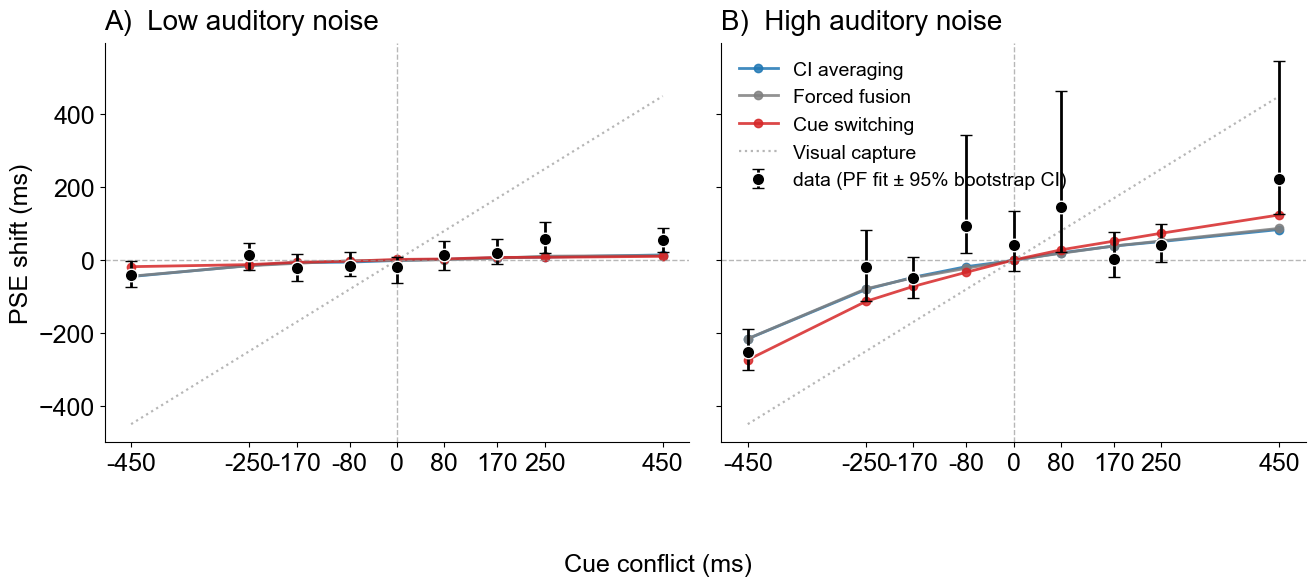

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 6), sharey=True)
panel_prefix = ['A)', 'B)']
for idx, n in enumerate(noise_levels):
    ax  = axes[idx]
    emp = emp_by_noise[n].sort_values('conflict')
    boot = boot_by_noise[n].sort_values('conflict')
    # Empirical points: point fit centre + bootstrap percentile CI as error bars.
    merged = emp.merge(boot[['conflict', 'mu_lo', 'mu_hi']], on='conflict', how='left')
    y     = mu_to_shift_s(merged['mu'].values) * 1000
    ylo   = mu_to_shift_s(merged['mu_lo'].values) * 1000
    yhi   = mu_to_shift_s(merged['mu_hi'].values) * 1000
    ax.errorbar(merged['conflict'].values * 1000, y,
                yerr=[np.maximum(0, y - ylo), np.maximum(0, yhi - y)],
                fmt='o', color='black', ms=9, lw=2, capsize=4, capthick=1.4,
                mfc='black', mec='white', mew=1.0,
                label='data (PF fit ± 95% bootstrap CI)', zorder=5)
    # Model prediction lines.
    for m in MODELS:
        pred = pred_by_model_noise[m][n].sort_values('conflict')
        ax.plot(pred['conflict'] * 1000, mu_to_shift_s(pred['mu']) * 1000,
                '-o', color=COLORS[m], lw=2, ms=6, alpha=0.85,
                label=DISPLAY[m])
    ax.axhline(0, color='#999999', linestyle='--', linewidth=1.0, alpha=0.7)
    ax.axvline(0, color='#999999', linestyle='--', linewidth=1.0, alpha=0.7)
    cf_ms = sorted(set(int(round(c * 1000)) for c in emp['conflict']))
    ax.plot(cf_ms, cf_ms, color='#aaaaaa', linestyle=':', linewidth=1.6, alpha=0.85,
            label='Visual capture' if idx == 1 else None)
    ax.set_title(f'{panel_prefix[idx]}  {noise_labels[n]}',
                 fontsize=FONT_SIZE_TITLE, loc='left', pad=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks(cf_ms)
    ax.set_xticklabels([str(t) for t in cf_ms], fontsize=FONT_SIZE_LABEL - 4)
    ax.tick_params(labelsize=FONT_SIZE_LABEL)
    if idx == 1:
        ax.legend(fontsize=FONT_SIZE_LEGEND - 2, frameon=False, loc='upper left')
axes[0].set_ylabel('PSE shift (ms)', fontsize=FONT_SIZE_LABEL)
fig.supxlabel('Cue conflict (ms)', fontsize=FONT_SIZE_LABEL, x=0.5)
plt.tight_layout(rect=(0, 0.05, 1.0, 1))
fig.savefig(f'{DATA_NAME}_pse_models_vs_data.pdf', dpi=600, bbox_inches='tight')
fig.savefig(f'{DATA_NAME}_pse_models_vs_data.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Plot — model-predicted psychometric σ vs conflict

PF σ is plotted in unitless form: raw log-space σ in `lognormal` mode, or σ divided by the standard duration in `normal` mode. This keeps the slope plot dimensionless across modes.

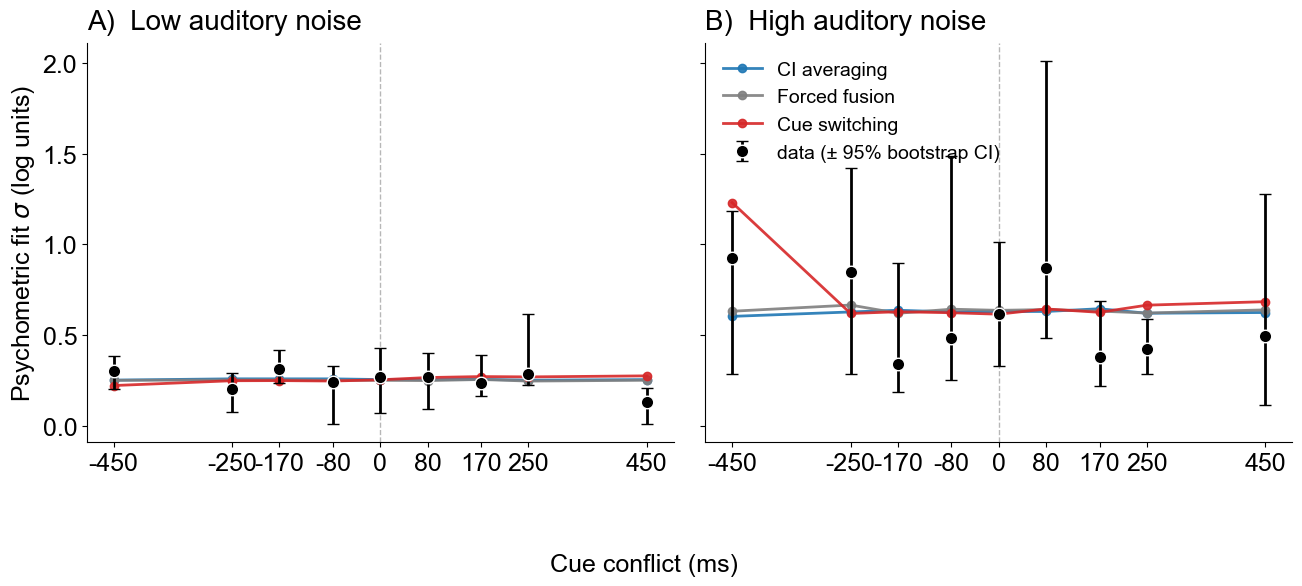

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 6), sharey=True)
panel_prefix = ['A)', 'B)']

for idx, n in enumerate(noise_levels):
    ax = axes[idx]

    emp = emp_by_noise[n].sort_values('conflict')
    boot = boot_by_noise[n].sort_values('conflict')
    merged = emp.merge(boot[['conflict', 'sigma_lo', 'sigma_hi']], on='conflict', how='left')
    y   = sigma_to_plot_units(merged['sigma'].values)
    ylo = sigma_to_plot_units(merged['sigma_lo'].values)
    yhi = sigma_to_plot_units(merged['sigma_hi'].values)
    ax.errorbar(merged['conflict'].values * 1000, y,
                yerr=[np.maximum(0, y - ylo), np.maximum(0, yhi - y)],
                fmt='o', color='black', ms=9, lw=2, capsize=4, capthick=1.4,
                mfc='black', mec='white', mew=1.0,
                label='data (± 95% bootstrap CI)', zorder=5)

    for m in MODELS:
        pred = pred_by_model_noise[m][n].sort_values('conflict')
        ax.plot(pred['conflict'] * 1000, sigma_to_plot_units(pred['sigma'].values),
                '-o', color=COLORS[m], lw=2, ms=6, alpha=0.9,
                label=DISPLAY[m])

    cf_ms = sorted(set(int(round(c * 1000))
                       for c in emp['conflict']).union(
                       int(round(c * 1000))
                       for m in MODELS
                       for c in pred_by_model_noise[m][n]['conflict']))
    ax.axvline(0, color='#999999', linestyle='--', linewidth=1.0, alpha=0.7)
    ax.set_title(f'{panel_prefix[idx]}  {noise_labels[n]}',
                 fontsize=FONT_SIZE_TITLE, loc='left', pad=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks(cf_ms)
    ax.set_xticklabels([str(t) for t in cf_ms], fontsize=FONT_SIZE_LABEL - 4)
    ax.tick_params(labelsize=FONT_SIZE_LABEL)
    if idx == 1:
        ax.legend(fontsize=FONT_SIZE_LEGEND - 2, frameon=False, loc='upper left')

axes[0].set_ylabel(sigma_plot_label(), fontsize=FONT_SIZE_LABEL)
fig.supxlabel('Cue conflict (ms)', fontsize=FONT_SIZE_LABEL, x=0.5)
plt.tight_layout(rect=(0, 0.05, 1.0, 1))
fig.savefig(f'{DATA_NAME}_sigma_models_vs_conflict.pdf', dpi=600, bbox_inches='tight')
fig.savefig(f'{DATA_NAME}_sigma_models_vs_conflict.png', dpi=300, bbox_inches='tight')
plt.show()

## Files produced

- `oyExt_pse_models_vs_data.{pdf,png}` — PSE-vs-conflict with empirical PSEs and three model predictions overlaid, both audio-noise levels.
- `oyExt_sigma_models_vs_conflict.{pdf,png}` — psychometric-fit sigma vs conflict for each model prediction, both audio-noise levels.

Model summary (NLL, AIC, BIC, ΔAIC, ΔBIC) printed inline in section 2. For a more rigorous comparison bump `n_start=3` and `n_simul=2000` in section 2 — current settings prioritise speed.